# Sankey Chart

A Sankey chart shows how a quantity splits and merges as it flows between stages: each stage is a column of nodes and each flow a ribbon as thick as its value, so the chart answers *where does it go, and where is it lost*. This guide shows how to create Sankey charts with the [datachart.charts.SankeyChart](../../../references/charts/#datachart.charts.SankeyChart) function, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-sankey-chart), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import SankeyChart

## Basics

The examples in this guide share one dataset: the energy flow of a country, from the primary sources (oil, natural gas, coal, nuclear, wind, biomass, hydro and solar) through electricity generation to the four end-use sectors (transport, industrial, residential and commercial), and from there to the energy that does useful work (*energy services*) and the energy lost as waste heat (*rejected energy*). The figures are **illustrative**: they are shaped like the national energy flow charts that the Lawrence Livermore National Laboratory publishes for the United States, but they are not a published table. They are scaled so the primary sources add up to 100, so every value reads as a percentage of the primary energy. The data lives in a hidden cell as `energy`. The story is the one those charts are known for: most of the energy a country uses is lost before it does anything useful.

In [2]:
# illustrative national energy flow, scaled so the primary sources sum to 100
ENERGY_FLOWS = [
    # primary source -> electricity or an end-use sector
    ("Solar", "Electricity", 3), ("Wind", "Electricity", 5), ("Hydro", "Electricity", 3),
    ("Nuclear", "Electricity", 8), ("Natural gas", "Electricity", 13), ("Coal", "Electricity", 9),
    ("Natural gas", "Residential", 5), ("Natural gas", "Commercial", 4),
    ("Natural gas", "Industrial", 10), ("Natural gas", "Transport", 1),
    ("Coal", "Industrial", 1),
    ("Oil", "Residential", 1), ("Oil", "Commercial", 1),
    ("Oil", "Industrial", 8), ("Oil", "Transport", 24),
    ("Biomass", "Industrial", 2), ("Biomass", "Transport", 2),
    # electricity -> sectors, and the generation losses
    ("Electricity", "Residential", 5), ("Electricity", "Commercial", 4),
    ("Electricity", "Industrial", 3), ("Electricity", "Rejected energy", 29),
    # sectors -> useful work and waste heat
    ("Residential", "Energy services", 7), ("Residential", "Rejected energy", 4),
    ("Commercial", "Energy services", 6), ("Commercial", "Rejected energy", 3),
    ("Industrial", "Energy services", 12), ("Industrial", "Rejected energy", 12),
    ("Transport", "Energy services", 6), ("Transport", "Rejected energy", 21),
]
energy = {"links": [{"source": s, "target": t, "value": v} for s, t, v in ENERGY_FLOWS]}

The data is one dictionary with a `links` list. Each link is a record with the `source` node, the `target` node, and the `value` that flows between them; a node is just its name, which is also its label:

In [3]:
energy["links"][:3]

[{'source': 'Solar', 'target': 'Electricity', 'value': 3},
 {'source': 'Wind', 'target': 'Electricity', 'value': 5},
 {'source': 'Hydro', 'target': 'Electricity', 'value': 3}]

Every `value` must be above zero, a link cannot join a node to itself, and the links cannot form a cycle; each of these raises a `ValueError`.

**Basic example.** Only the `data` argument is required. Each node's column is its longest path from any source, so the sources sit on the left and the two outcomes on the right. The sectors that draw on electricity land in the third column, but transport takes no electricity here, so it sits in the second column beside it; [Node columns](#node-columns) moves it. A node's height is the larger of what flows in and what flows out, and each ribbon takes the color of the node it leaves:

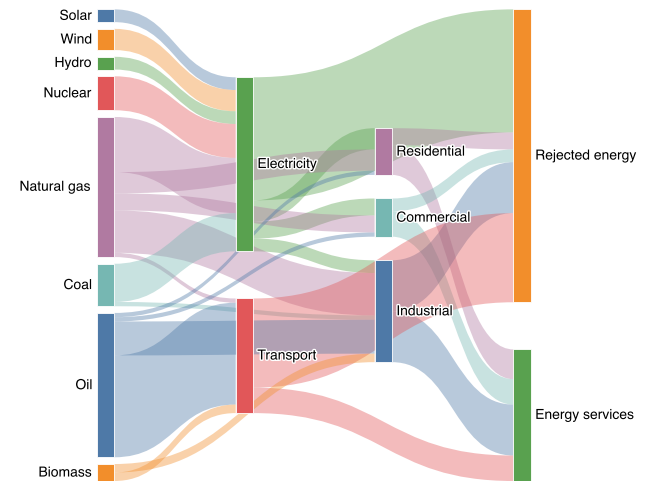

In [4]:
SankeyChart(
    # add the data to the chart
    data=energy
).show()

## Customizing the Sankey Chart

Every customization is either a keyword argument of `SankeyChart` or a `plot_sankey_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title                                 | `title`                                                                 | [Title and figure size](#title-and-figure-size) |
| resize the figure                           | `figsize`                                                               | [Title and figure size](#title-and-figure-size) |
| set the columns or reorder the nodes        | `nodes`                                                                 | [Node columns](#node-columns) |
| head the columns                            | `column_labels`                                                         | [Column labels and ribbon values](#column-labels-and-ribbon-values) |
| write the flow values on the ribbons        | `show_values`, `value_format`                                           | [Column labels and ribbon values](#column-labels-and-ribbon-values) |
| color the ribbons by target                 | `style={"plot_sankey_link_color": "target"}`                            | [Node and ribbon style](#node-and-ribbon-style) |
| change the node width, gaps, or stroke      | `style={"plot_sankey_node_width": ..., "plot_sankey_node_pad": ...}`    | [Node and ribbon style](#node-and-ribbon-style) |
| grey the ribbons, or outline the nodes      | `style={"plot_sankey_link_color": "grey", "plot_sankey_node_fill": False}` | [Grey ribbons and emphasis](#grey-ribbons-and-emphasis) |
| change the halo behind the labels           | `style={"plot_sankey_label_halo_width": ...}`                           | [Grey ribbons and emphasis](#grey-ribbons-and-emphasis) |
| put a note on the chart                     | `texts`                                                                 | [Text annotations](#text-annotations) |
| draw several Sankeys in one figure          | `data` as a list, `subtitle`, `max_cols`                                | [Subplots](#subplots) |
| arrange a Sankey next to other charts       | `Grid`                                                                  | [Composing with Grid](#composing-with-grid) |
| restyle every chart at once                 | `config.set_theme`                                                      | [Themes](#themes) |
| save the chart to a file                    | `save_figure`                                                           | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `value_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |

The full list of style attributes is in the [datachart.typings.SankeyStyleAttrs](../../../references/typings/#datachart.typings.SankeyStyleAttrs) type; the full list of parameters is in the [datachart.charts.SankeyChart](../../../references/charts/#datachart.charts.SankeyChart) reference.

### Title and figure size

A Sankey chart without a title leaves the reader guessing what flows; `title` says it. A Sankey has no axes, so there are no axis labels to set: the node names carry the meaning. With eight sources and four sectors the default figure is crowded, and `figsize` gives the nodes room: a `(width, height)` tuple in inches or one of the presets in [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE), sized for a full or half page width.

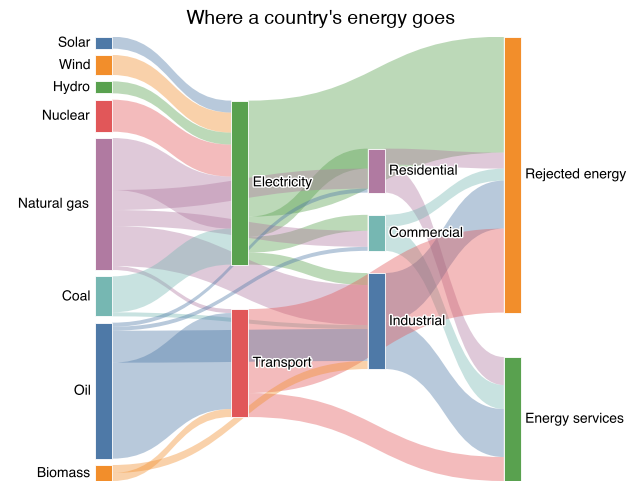

In [5]:
from datachart.constants import FIG_SIZE

SankeyChart(
    data=energy,
    # add the title
    title="Where a country's energy goes",
    # a full-width figure with room for the labels
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Node columns

The inferred layout splits the sectors over two columns and keeps the nodes in the order they first appear in the links, which is rarely the layout that tells the story. `nodes` sets the columns yourself: a list of columns, left to right, each a list of node names, top to bottom. It must name every node in the links exactly once, and it fixes the vertical order too, so it is the way to sort the nodes. The example puts all four sectors in one column, ranks the sources by size, puts the sectors in the order of their intake, and keeps *Energy services* above *Rejected energy*.

A node that stops early (a leaf reached in one hop) stays in the column it was reached in by default; with `nodes`, it can sit in any column to the right of its sources.

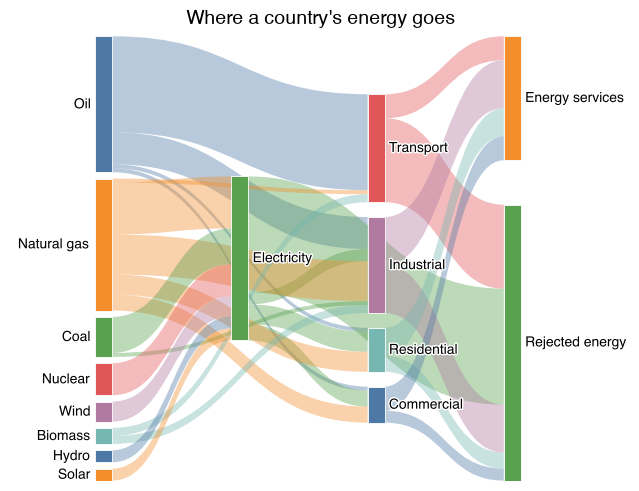

In [6]:
# largest source first; the order within a column is top to bottom
ENERGY_NODES = [
    ["Oil", "Natural gas", "Coal", "Nuclear", "Wind", "Biomass", "Hydro", "Solar"],
    ["Electricity"],
    ["Transport", "Industrial", "Residential", "Commercial"],
    ["Energy services", "Rejected energy"],
]

SankeyChart(
    data=energy,
    # set the columns and the order of the nodes
    nodes=ENERGY_NODES,
    title="Where a country's energy goes",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Column labels and ribbon values

Four columns of names do not say what each column stands for; `column_labels` heads them, one label per column, left to right, in the subtitle style. When the exact amounts matter, `show_values` writes each flow's value at the end of its ribbon, just before the node it enters, and `value_format` formats it: a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) constant (`VALUE_FORMAT.THOUSANDS` for large counts, as in [Example 2](#example-2-where-does-a-signup-funnel-leak-explicit-columns-grey-ribbons-and-a-note)) or any `"{x:.1f}"`, `"{:.1f}%"` or `"%g"` style string. The values here are already percentages of the primary energy, so a positional `"{:.0f}%"` string appends the sign (`VALUE_FORMAT.PERCENT` would multiply by 100). A ribbon too thin for its value slides the value along the ribbon to the first clear spot.

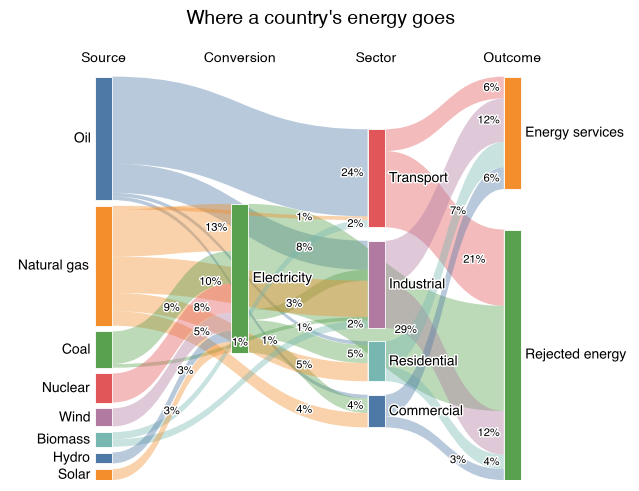

In [7]:
from datachart.constants import VALUE_FORMAT

SankeyChart(
    data=energy,
    nodes=ENERGY_NODES,
    # head the four columns
    column_labels=["Source", "Conversion", "Sector", "Outcome"],
    # write each flow as a share of the primary energy
    show_values=True,
    value_format="{:.0f}%",
    title="Where a country's energy goes",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Node and ribbon style

The ribbons take the color of the node they leave, which answers *where does this flow come from*. `plot_sankey_link_color` switches the question: `"target"` colors each ribbon like the node it enters, so the two outcomes read across the whole chart and the color of the rejected energy shows how much of every sector's intake is lost. `plot_sankey_link_alpha` sets the ribbon alpha. `plot_sankey_node_width` is the width of the node bars and `plot_sankey_node_pad` the vertical room shared by the gaps of the tallest column, both as fractions of the drawing; `plot_sankey_node_edge_color` and `plot_sankey_node_edge_width` draw the stroke around every node. The attributes are listed in [datachart.typings.SankeyStyleAttrs](../../../references/typings/#datachart.typings.SankeyStyleAttrs), and any attribute left out keeps the value of the active theme.

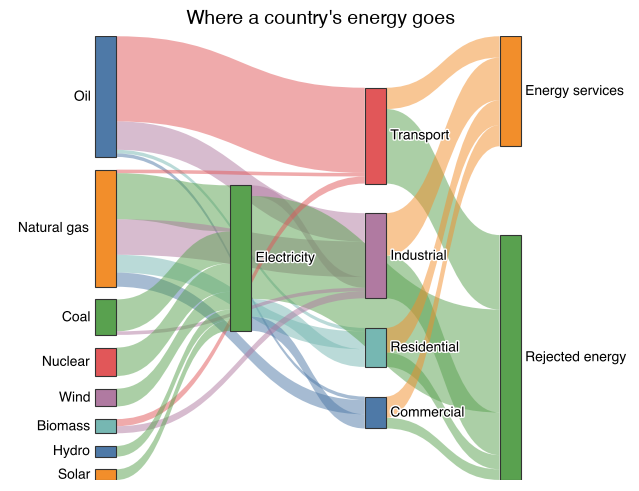

In [8]:
SankeyChart(
    data=energy,
    nodes=ENERGY_NODES,
    style={
        # ribbons in the color of the node they enter
        "plot_sankey_link_color": "target",
        "plot_sankey_link_alpha": 0.5,
        # wider nodes, more room between them, a dark stroke
        "plot_sankey_node_width": 0.05,
        "plot_sankey_node_pad": 0.2,
        "plot_sankey_node_edge_color": "#333333",
        "plot_sankey_node_edge_width": 0.8,
    },
    title="Where a country's energy goes",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Grey ribbons and emphasis

Other charts point the reader at a few marks with `emphasis`, but a Sankey has no series to highlight or mute, so passing `emphasis` raises a `ValueError` (the [Highlighting](../../styling/highlighting/) guide covers the charts that support it). The quiet alternative is `"grey"` for `plot_sankey_link_color`: the ribbons turn neutral and only the nodes carry color, which suits a chart about the stages rather than the individual flows. `plot_sankey_node_fill=False` draws the nodes as outlines, and `plot_sankey_label_halo_width` sets the halo, in the background color, that keeps the labels readable over the ribbons; `0` drops it.

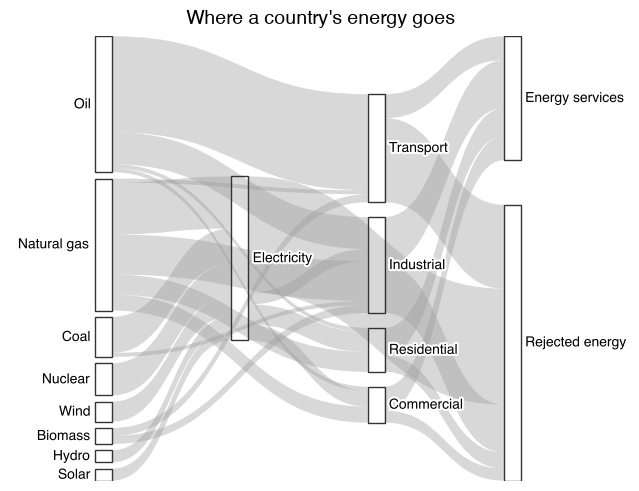

In [9]:
SankeyChart(
    data=energy,
    nodes=ENERGY_NODES,
    style={
        # neutral ribbons, outlined nodes
        "plot_sankey_link_color": "grey",
        "plot_sankey_node_fill": False,
        "plot_sankey_node_edge_color": "#333333",
        "plot_sankey_node_edge_width": 1.0,
        # a wider halo behind the labels
        "plot_sankey_label_halo_width": 3,
    },
    title="Where a country's energy goes",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Text annotations

A Sankey shows the losses; a note states the number. `texts` places text on the chart ([TextSettingAttrs](../../../references/typings/#datachart.typings.TextSettingAttrs)). The columns span `0` to `1` horizontally and the tallest column `0` to `1` vertically, so data coordinates and axes fractions (`"coords": "axes"`) are nearly the same thing. The [Text Annotations](../../utility/annotations/) guide covers placement, connectors and styling. The note sums the rejected energy from the data, and its `target` draws a connector to the *Rejected energy* node.

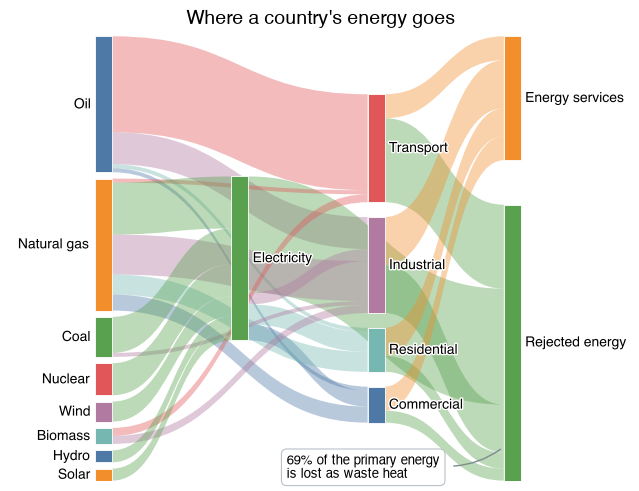

In [10]:
rejected = sum(link["value"] for link in energy["links"] if link["target"] == "Rejected energy")

SankeyChart(
    data=energy,
    nodes=ENERGY_NODES,
    style={"plot_sankey_link_color": "target"},
    # the share of the primary energy lost as waste heat
    texts={
        "text": f"{rejected}% of the primary energy\nis lost as waste heat",
        "x": 0.45,
        "y": 0.03,
        "target": (0.965, 0.08),
    },
    title="Where a country's energy goes",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Multiple Sankey Charts

### Subplots

Two flows compare best in one figure. A list of `{"links": [...]}` dictionaries draws one Sankey per subplot; there is no overlay of two Sankeys on one drawing, so `subplots` is implied. `subtitle` titles each Sankey, `title` stays global, and `max_cols` limits the Sankeys per row. `energy_2050`, defined in a hidden cell, is an equally **illustrative** future for the same country: more wind and solar, electric transport and heating, and less primary energy (80 instead of 100, on the same scale). Stacked one above the other, the two charts show the future delivering more energy services (39 instead of 31) from less primary energy, because less of it is burned. `nodes` and `column_labels` apply to every subplot, so the example leaves them out.

In [11]:
# an illustrative 2050 scenario on the same scale (today's primary energy = 100)
ENERGY_FLOWS_2050 = [
    ("Solar", "Electricity", 15), ("Wind", "Electricity", 20), ("Hydro", "Electricity", 4),
    ("Nuclear", "Electricity", 9), ("Natural gas", "Electricity", 7), ("Coal", "Electricity", 1),
    ("Natural gas", "Residential", 2), ("Natural gas", "Commercial", 2),
    ("Natural gas", "Industrial", 4),
    ("Oil", "Industrial", 4), ("Oil", "Transport", 8),
    ("Biomass", "Industrial", 2), ("Biomass", "Transport", 2),
    ("Electricity", "Residential", 9), ("Electricity", "Commercial", 8),
    ("Electricity", "Industrial", 9), ("Electricity", "Transport", 10),
    ("Electricity", "Rejected energy", 20),
    ("Residential", "Energy services", 8), ("Residential", "Rejected energy", 3),
    ("Commercial", "Energy services", 7), ("Commercial", "Rejected energy", 3),
    ("Industrial", "Energy services", 11), ("Industrial", "Rejected energy", 8),
    ("Transport", "Energy services", 13), ("Transport", "Rejected energy", 7),
]
energy_2050 = {"links": [{"source": s, "target": t, "value": v} for s, t, v in ENERGY_FLOWS_2050]}

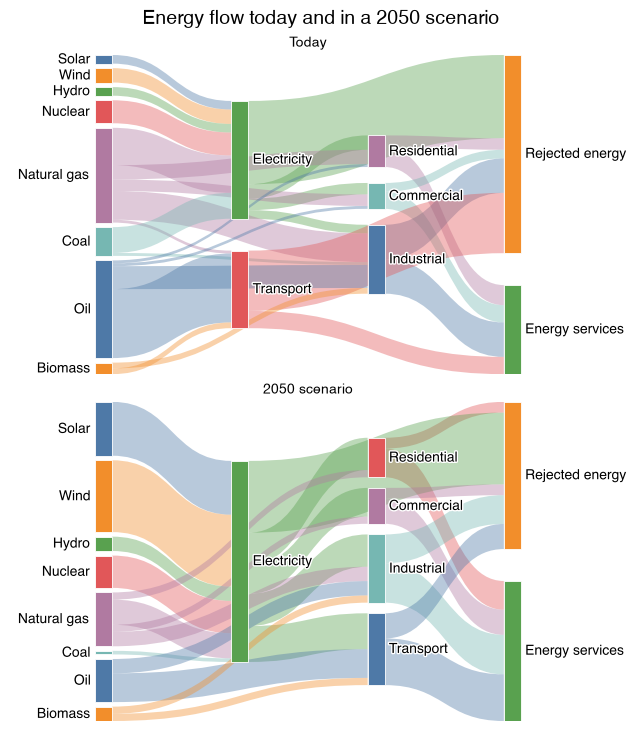

In [12]:
SankeyChart(
    # one Sankey per scenario
    data=[energy, energy_2050],
    subtitle=["Today", "2050 scenario"],
    # one above the other
    max_cols=1,
    title="Energy flow today and in a 2050 scenario",
    figsize=FIG_SIZE.FULL_TALL,
).show()

### Composing with Grid

A Sankey owns its drawing: its 0 to 1 layout is not a coordinate space another chart can share, so [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) rejects a Sankey figure. [datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) arranges it next to other charts, each in its own cell, and a `layout_spec` lets a cell span more than one row or column; the [Grid](../../utility/grid/) guide covers the layout options. The Sankey shows where the energy goes, but not how efficient each sector is, so a [BarChart](../../../references/charts/#datachart.charts.BarChart) below it prints the share of each sector's intake that becomes useful work, computed from the same links: transport, the largest sector, wastes the most.

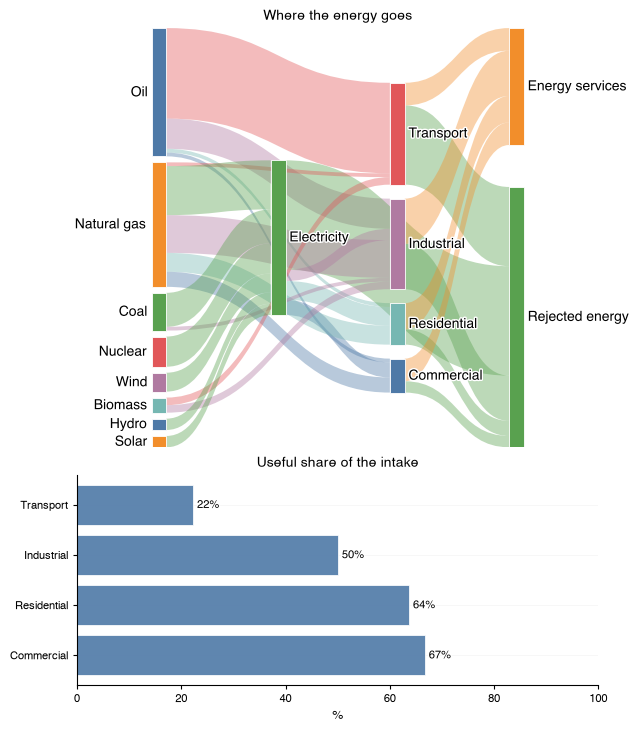

In [13]:
from datachart.charts import BarChart
from datachart.constants import ORIENTATION
from datachart.utils import Grid

SECTORS = ["Transport", "Industrial", "Residential", "Commercial"]


def efficiency(flows, sector):
    # the share of a sector's intake that becomes energy services
    intake = sum(link["value"] for link in flows["links"] if link["target"] == sector)
    useful = sum(
        link["value"]
        for link in flows["links"]
        if link["source"] == sector and link["target"] == "Energy services"
    )
    return useful / intake


flows = SankeyChart(
    data=energy,
    nodes=ENERGY_NODES,
    style={"plot_sankey_link_color": "target"},
    title="Where the energy goes",
)
sector_efficiency = BarChart(
    # reversed, so the first sector ends up at the top
    data=[{"label": s, "y": 100 * efficiency(energy, s)} for s in SECTORS[::-1]],
    orientation=ORIENTATION.HORIZONTAL,
    show_values=True,
    value_format="{:.0f}%",
    title="Useful share of the intake",
    xlabel="%",
    xmin=0,
    xmax=100,
)
Grid(
    [
        # the Sankey spans two of the three rows
        {"figure": flows, "layout_spec": {"row": 0, "col": 0, "rowspan": 2, "colspan": 1}},
        {"figure": sector_efficiency, "layout_spec": {"row": 2, "col": 0, "rowspan": 1, "colspan": 1}},
    ],
    figsize=FIG_SIZE.FULL_TALL,
).show()

## Additional Features

### Themes

A theme sets the palette, the node stroke, the ribbon alpha and the fonts of every chart at once, which is the way to restyle a whole document. Apply one with [datachart.config.Config.set_theme](../../../references/config/#datachart.config.Config.set_theme) and a [THEME](../../../references/constants/#datachart.constants.THEME) member, as the [Themes](../../styling/themes/) guide shows; the [Theme Gallery](../../styling/theme-gallery/) shows every chart under each theme. Style is resolved when the chart is created, so a theme set before the call and reset after it applies to that chart alone. The `QUILL` theme draws the nodes as ink outlines over faint ribbons.

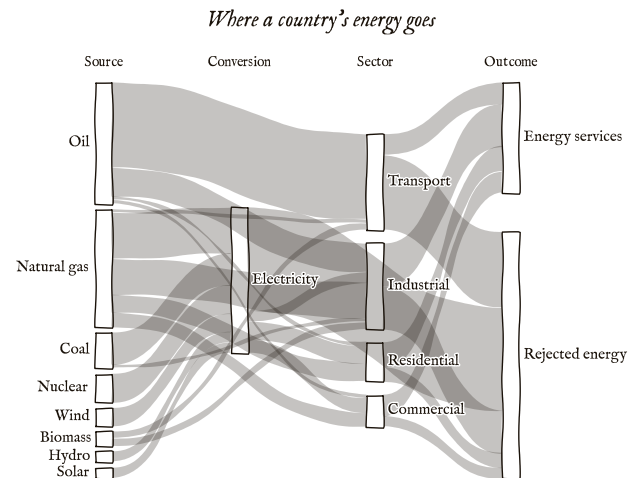

In [14]:
from datachart.config import config
from datachart.constants import THEME

config.set_theme(THEME.QUILL)
figure = SankeyChart(
    data=energy,
    nodes=ENERGY_NODES,
    column_labels=["Source", "Conversion", "Sector", "Outcome"],
    title="Where a country's energy goes",
    figsize=FIG_SIZE.FULL_MEDIUM,
)
config.reset_config()
figure.show()

## Real-World Examples

The examples below put the features above to work, each one answering a question about where something goes. The data lives in hidden cells; each example says what its data is and where it comes from.

### Example 1: Where Do Two Annotators Disagree? (Inferred Columns, Column Labels, and Ribbons by Source)

Two annotators labeled the same 150 sentences as positive, neutral or negative, and an adjudicator settled the final label. The counts in `agreement` are **illustrative**. The node names carry the annotator (`pos (A)`, `pos (B)`), so the same label becomes a separate node in each column, and the inferred layout puts A, B and the final label in three columns. With the ribbons colored by their source, the wide ribbons are the agreements and the thin crossing ones the disagreements: A's neutral sentences scatter the most, and the final column shows that the adjudicator mostly kept B's label.

In [15]:
# illustrative label counts: annotator A -> annotator B -> final label
AGREEMENT = [
    ("pos (A)", "pos (B)", 40), ("pos (A)", "neu (B)", 8), ("pos (A)", "neg (B)", 2),
    ("neu (A)", "neu (B)", 25), ("neu (A)", "pos (B)", 6), ("neu (A)", "neg (B)", 5),
    ("neg (A)", "neg (B)", 30), ("neg (A)", "neu (B)", 4),
    ("pos (B)", "pos", 44), ("pos (B)", "neu", 2),
    ("neu (B)", "neu", 33), ("neu (B)", "pos", 2), ("neu (B)", "neg", 2),
    ("neg (B)", "neg", 35), ("neg (B)", "neu", 2),
]
agreement = {"links": [{"source": s, "target": t, "value": v} for s, t, v in AGREEMENT]}

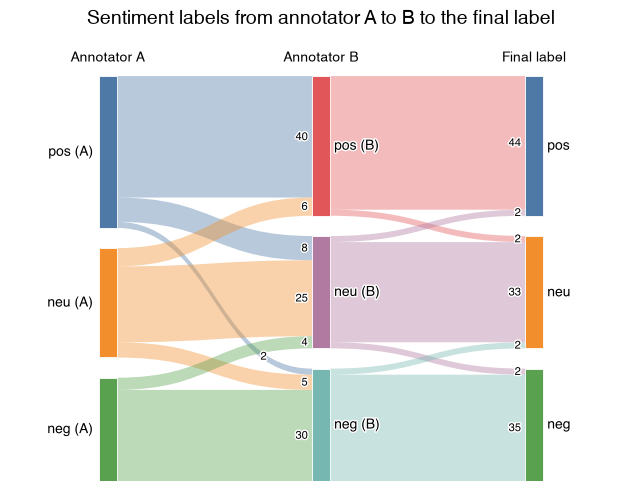

In [16]:
SankeyChart(
    data=agreement,
    # the inferred columns, headed
    column_labels=["Annotator A", "Annotator B", "Final label"],
    show_values=True,
    title="Sentiment labels from annotator A to B to the final label",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 2: Where Does a Signup Funnel Leak? (Explicit Columns, Grey Ribbons, and a Note)

A thousand visitors either bounce or sign up; the signups activate or churn, and the activated users pay or stay on the free tier. The counts in `FUNNEL` are **illustrative**. By default each drop-off sits in the column where it happens, and the explicit `nodes` keep that layout while putting the continuing flow on top at every stage, so the funnel narrows along the top edge and the leaks fall away below it. Grey ribbons leave the color to the stages, the values print with a thousands separator, and a note states the conversion, computed from the data.

In [17]:
# an illustrative signup funnel of 1,000 visitors
FUNNEL = [
    ("Visited", "Signed up", 300), ("Visited", "Bounced", 700),
    ("Signed up", "Activated", 180), ("Signed up", "Churned", 120),
    ("Activated", "Paid", 90), ("Activated", "Free tier", 90),
]
funnel = {"links": [{"source": s, "target": t, "value": v} for s, t, v in FUNNEL]}

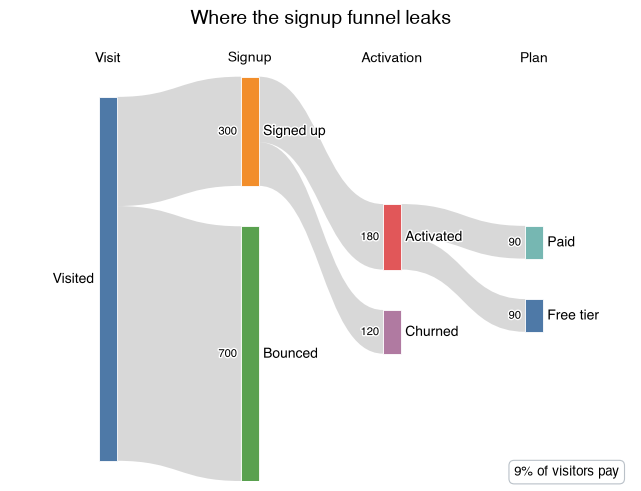

In [18]:
visitors = sum(v for s, t, v in FUNNEL if s == "Visited")
paying = sum(v for s, t, v in FUNNEL if t == "Paid")

SankeyChart(
    data=funnel,
    # the continuing flow on top, the drop-off below it
    nodes=[["Visited"], ["Signed up", "Bounced"], ["Activated", "Churned"], ["Paid", "Free tier"]],
    column_labels=["Visit", "Signup", "Activation", "Plan"],
    show_values=True,
    value_format=VALUE_FORMAT.THOUSANDS,
    style={"plot_sankey_link_color": "grey"},
    texts={
        "text": f"{paying / visitors:.0%} of visitors pay",
        "x": 0.98,
        "y": 0.02,
        "coords": "axes",
        "style": {"plot_text_halign": "right"},
    },
    title="Where the signup funnel leaks",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 3: Who Survived the Titanic? (Explicit Order, Values, and a Grid with a Bar Chart)

`TITANIC` holds the 2,201 people aboard the Titanic, counted by class (first, second, third or crew), sex, and whether they survived; the counts are the classic `Titanic` table shipped with R, with children and adults combined. The Sankey follows everyone from their class through their sex to the outcome, with the women above the men and the survivors above the lost, and prints the counts. A Sankey shows the sizes of the flows but not the rates, so a [BarChart](../barchart/) of the survival rate per class goes beside it, and [Grid](../../utility/grid/) sets the two in one figure: most crew members and third-class passengers were lost, and first class had the best odds.

In [19]:
# Titanic passengers and crew by class, sex and survival (R's Titanic table, ages combined)
TITANIC = {
    ("1st", "Male"): {"Survived": 62, "Lost": 118},
    ("1st", "Female"): {"Survived": 141, "Lost": 4},
    ("2nd", "Male"): {"Survived": 25, "Lost": 154},
    ("2nd", "Female"): {"Survived": 93, "Lost": 13},
    ("3rd", "Male"): {"Survived": 88, "Lost": 422},
    ("3rd", "Female"): {"Survived": 90, "Lost": 106},
    ("Crew", "Male"): {"Survived": 192, "Lost": 670},
    ("Crew", "Female"): {"Survived": 20, "Lost": 3},
}
CLASSES = ["1st", "2nd", "3rd", "Crew"]
SEXES = ["Female", "Male"]

# class -> sex, then sex -> outcome
titanic = {
    "links": [
        {"source": cls, "target": sex, "value": sum(TITANIC[(cls, sex)].values())}
        for cls in CLASSES
        for sex in SEXES
    ]
    + [
        {"source": sex, "target": outcome, "value": sum(TITANIC[(cls, sex)][outcome] for cls in CLASSES)}
        for sex in SEXES
        for outcome in ("Survived", "Lost")
    ]
}
survival_rate = [
    {
        "label": cls,
        "y": 100 * sum(TITANIC[(cls, sex)]["Survived"] for sex in SEXES)
        / sum(sum(TITANIC[(cls, sex)].values()) for sex in SEXES),
    }
    for cls in CLASSES
]

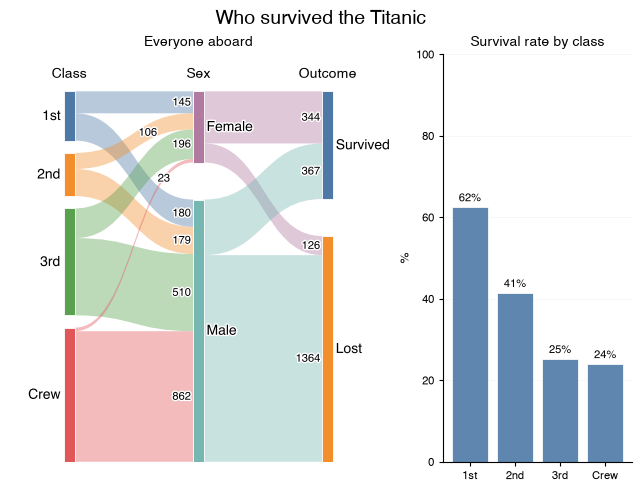

In [20]:
voyage = SankeyChart(
    data=titanic,
    # women above men, survivors above the lost
    nodes=[CLASSES, SEXES, ["Survived", "Lost"]],
    column_labels=["Class", "Sex", "Outcome"],
    show_values=True,
    title="Everyone aboard",
)
rates = BarChart(
    data=survival_rate,
    show_values=True,
    value_format="{:.0f}%",
    title="Survival rate by class",
    ylabel="%",
    ymin=0,
    ymax=100,
)
Grid(
    [
        # the Sankey spans two of the three columns
        {"figure": voyage, "layout_spec": {"row": 0, "col": 0, "rowspan": 1, "colspan": 2}},
        {"figure": rates, "layout_spec": {"row": 0, "col": 2, "rowspan": 1, "colspan": 1}},
    ],
    title="Who survived the Titanic",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()